In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers

if tf.config.list_physical_devices('GPU'):
    tf.config.set_visible_devices([], 'GPU')
    print("GPU is enabled")
if tf.config.list_physical_devices('MPS'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('MPS')[0], True)
    print("MPS is enabled")


## Slide 2: Lớp Convolutional (CNN – Conv2D)

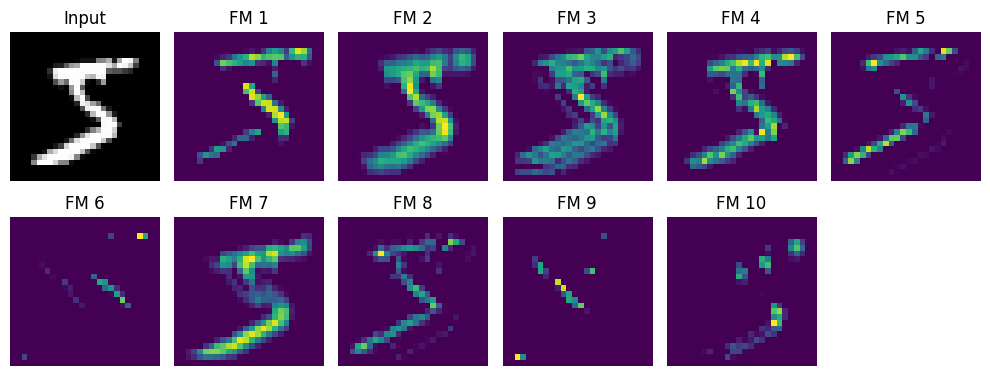

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Lấy một ảnh đầu tiên từ MNIST và reshape thành (28, 28, 1)
sample_img = x_train[0].reshape(1, 28, 28, 1).astype("float32") / 255.0

# Tạo 1 Conv2D layer
conv_layer = tf.keras.layers.Conv2D(32, (3, 3), activation="relu")

# Áp dụng conv layer lên ảnh
feature_maps = conv_layer(sample_img)

# Hiển thị ảnh gốc và một vài feature map
plt.figure(figsize=(10, 4))

# Ảnh gốc
plt.subplot(2, 6, 1)
plt.imshow(sample_img[0, :, :, 0], cmap="gray")
plt.title("Input")
plt.axis("off")

# Hiển thị 10 feature maps đầu tiên
for i in range(10):
    plt.subplot(2, 6, i+2)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.title(f"FM {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Slide 3: Lớp Pooling (MaxPooling)


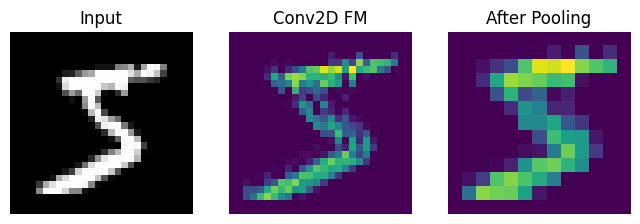

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST và lấy 1 ảnh đầu tiên
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
sample_img = x_train[0].reshape(1, 28, 28, 1).astype("float32") / 255.0

# Conv layer để tạo feature maps
conv_layer = tf.keras.layers.Conv2D(8, (3, 3), activation="relu")
feature_maps = conv_layer(sample_img)

# MaxPooling 2x2
pool_layer = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
pooled_maps = pool_layer(feature_maps)

# Hiển thị ảnh gốc, 1 feature map và feature map sau pooling
plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.imshow(sample_img[0,:,:,0], cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(feature_maps[0,:,:,0], cmap="viridis")
plt.title("Conv2D FM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pooled_maps[0,:,:,0], cmap="viridis")
plt.title("After Pooling")
plt.axis("off")

plt.show()


## Slide 4: Lớp Dropout


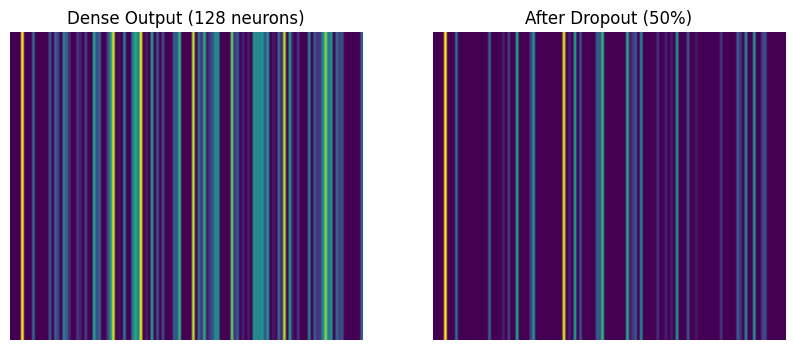

In [ ]:
import numpy as np

# Flatten ảnh MNIST
flat_img = sample_img.reshape(1, -1)

# Dense + Dropout
dense_layer = tf.keras.layers.Dense(128, activation="relu")
dropout_layer = tf.keras.layers.Dropout(0.5)

h = dense_layer(flat_img)
h_drop = dropout_layer(h, training=True)

# Vẽ vector trước và sau dropout
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(h.numpy(), aspect="auto", cmap="viridis")
plt.title("Dense Output (128 neurons)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(h_drop.numpy(), aspect="auto", cmap="viridis")
plt.title("After Dropout (50%)")
plt.axis("off")

plt.show()


In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [4]:

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs) 
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x) 
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x) 
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x) 
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 3, 3, 128)         73856 

In [5]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data() 
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255 
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",               metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 [==============================] - 18s 19ms/step - loss: 0.1555 - accuracy: 0.9523
Epoch 2/5
938/938 [==============================] - 18s 20ms/step - loss: 0.0434 - accuracy: 0.9865
Epoch 3/5
792/938 [========================>.....] - ETA: 3s - loss: 0.0301 - accuracy: 0.9907

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.0253 - accuracy: 0.9917


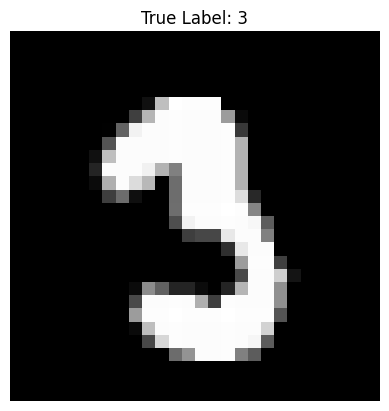

1/1 [==============================] - 0s 10ms/step
Predicted Label: 3


In [ ]:
import random
import numpy as np

import matplotlib.pyplot as plt

# Select a random index from the test dataset
random_index = random.randint(0, len(test_images) - 1)

# Get the random test image and its true label
random_test_image = test_images[random_index]
true_label = test_labels[random_index]

# Display the random test image
plt.imshow(random_test_image.squeeze(), cmap="gray")
plt.title(f"True Label: {true_label}")
plt.axis("off")
plt.show()

# Predict the label using the trained model
predicted_label = np.argmax(model.predict(random_test_image.reshape(1, 28, 28, 1)))

# Display the predicted label
print(f"Predicted Label: {predicted_label}")

## Slide 6: Case study – Cats vs Dogs (baseline)

In [1]:

parsed = True
if not parsed:

    import os, shutil, pathlib
    original_dir = pathlib.Path("train")
    new_base_dir = pathlib.Path("cats_vs_dogs_small")
    def make_subset(subset_name, start_index, end_index):
        for category in ("cat", "dog"):
            dir = new_base_dir / subset_name / category
            os.makedirs(dir)
            fnames = [f"{i}.jpg" for i in range(start_index, end_index)]
            for fname in fnames:
                shutil.copyfile(src=original_dir / category / fname, dst=dir / f"{category}.{fname}")
    make_subset("train", start_index=0, end_index=1000)
    make_subset("validation", start_index=1000, end_index=1500)
    make_subset("test", start_index=1500, end_index=2500)



In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [2]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 89, 89, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                        

In [6]:
model.compile(loss="binary_crossentropy",optimizer="rmsprop",metrics=["accuracy"])

In [ ]:
if not parsed:

    from PIL import Image
    import os

    data_dir = "cats_vs_dogs_small/train/dog" # Thay đổi thành đường dẫn của bạn

    for subdir, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                file_path = os.path.join(subdir, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Kiểm tra tính toàn vẹn của tệp ảnh
                except (IOError, OSError) as e:
                    print(f"Lỗi: Tệp ảnh bị hỏng hoặc rỗng tại: {file_path}. Lỗi: {e}")

In [6]:
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")
from tensorflow.keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [7]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


In [11]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.h5",
        save_best_only=True,
        monitor="val_loss")
]

In [14]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/10
63/63 [==============================] - ETA: 0s - loss: 0.6527 - accuracy: 0.6525

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 13s 205ms/step - loss: 0.6527 - accuracy: 0.6525 - val_loss: 0.8748 - val_accuracy: 0.6020
Epoch 2/10
63/63 [==============================] - ETA: 0s - loss: 0.6211 - accuracy: 0.6660

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 14s 222ms/step - loss: 0.6211 - accuracy: 0.6660 - val_loss: 0.8111 - val_accuracy: 0.5830
Epoch 3/10
63/63 [==============================] - ETA: 0s - loss: 0.5965 - accuracy: 0.6940

...

63/63 [==============================] - 13s 200ms/step - loss: 0.4372 - accuracy: 0.7930 - val_loss: 0.9167 - val_accuracy: 0.6650
Epoch 9/10
63/63 [==============================] - ETA: 0s - loss: 0.3902 - accuracy: 0.8220

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 13s 204ms/step - loss: 0.3902 - accuracy: 0.8220 - val_loss: 0.6070 - val_accuracy: 0.7210
Epoch 10/10
63/63 [==============================] - ETA: 0s - loss: 0.3500 - accuracy: 0.8510

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 13s 201ms/step - loss: 0.3500 - accuracy: 0.8510 - val_loss: 0.6899 - val_accuracy: 0.7320


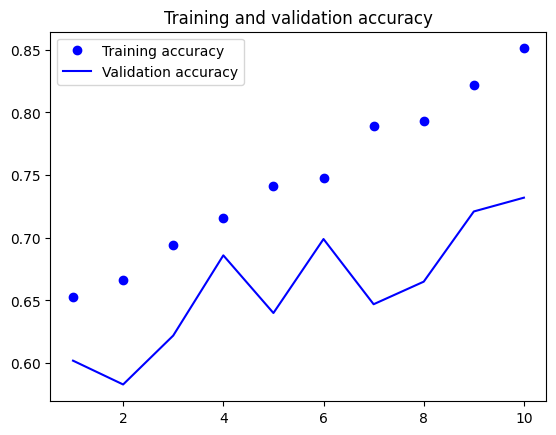

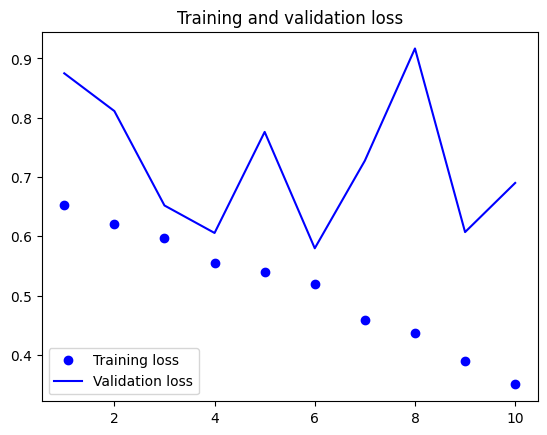

In [15]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Doan Code tren co accuracy rat thap do bi overfit.

## Data augmentation

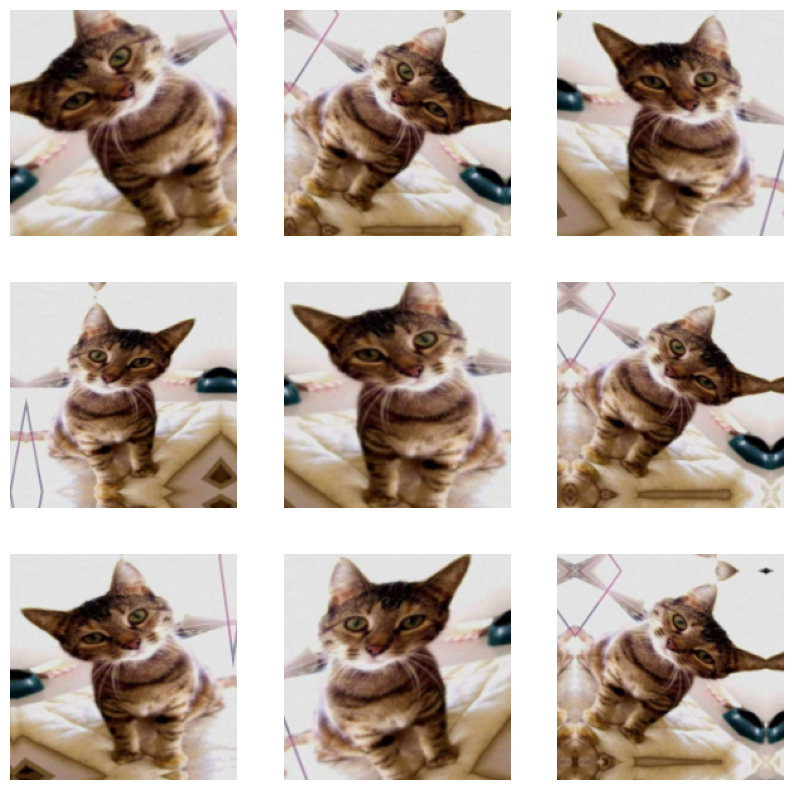

In [9]:
import matplotlib.pyplot as plt
data_augmentation = keras.Sequential(
[
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]
)

plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [10]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy",
optimizer="rmsprop",
metrics=["accuracy"])

In [11]:
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="convnet_from_scratch_with_augmentation.h5",
save_best_only=True,
monitor="val_loss")
]
history = model.fit(
train_dataset,
epochs=10,
validation_data=validation_dataset,
callbacks=callbacks)

Epoch 1/10
63/63 [==============================] - ETA: 0s - loss: 0.7430 - accuracy: 0.5375

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 14s 205ms/step - loss: 0.7430 - accuracy: 0.5375 - val_loss: 0.6825 - val_accuracy: 0.5000
Epoch 2/10


/Users/nguyenduchuy/Documents/CodeHTTM/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


63/63 [==============================] - ETA: 0s - loss: 0.6913 - accuracy: 0.5560

...

63/63 [==============================] - 17s 258ms/step - loss: 0.5888 - accuracy: 0.6990 - val_loss: 0.5854 - val_accuracy: 0.7070
Epoch 9/10
63/63 [==============================] - ETA: 0s - loss: 0.5862 - accuracy: 0.7080

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 13s 207ms/step - loss: 0.5862 - accuracy: 0.7080 - val_loss: 0.6013 - val_accuracy: 0.6590
Epoch 10/10
63/63 [==============================] - ETA: 0s - loss: 0.5783 - accuracy: 0.6945

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 [==============================] - 13s 199ms/step - loss: 0.5783 - accuracy: 0.6945 - val_loss: 0.5513 - val_accuracy: 0.7180


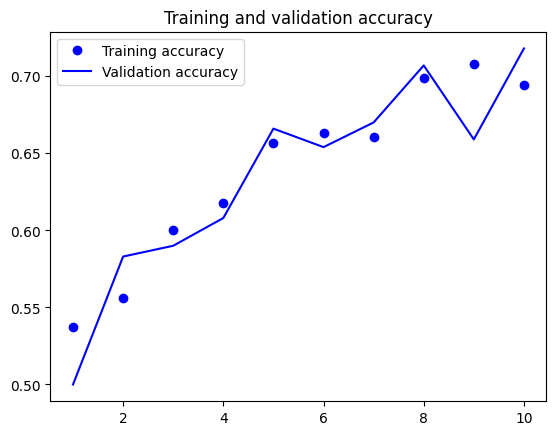

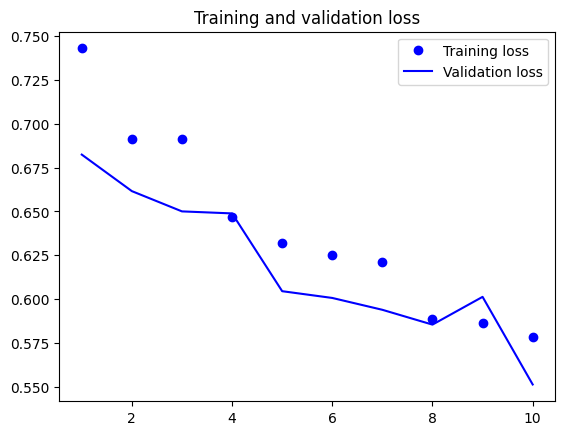

In [12]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model(
"convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

## Slide 8: Sử dụng model Pretrain VGG16

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
63/63 [==============================] - 2s 28ms/step - loss: 19.6364 - accuracy: 0.9165 - val_loss: 4.3201 - val_accuracy: 0.9660


c:\CodeHTTM\BTL-HTTM-2025\.venv\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


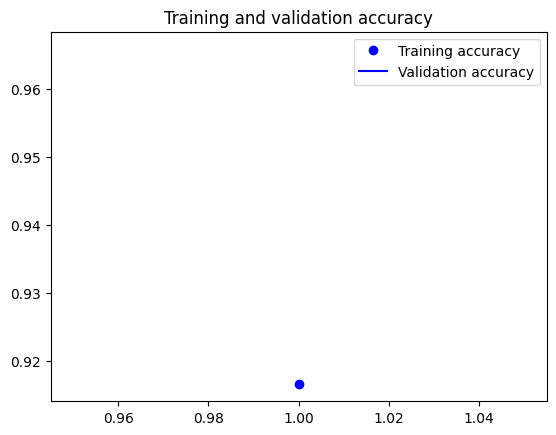

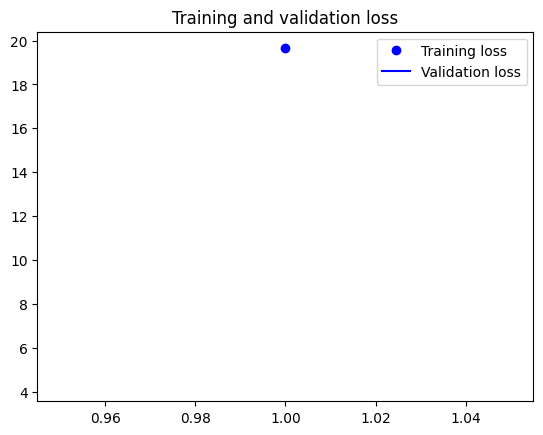

This is the number of trainable weights before freezing the conv base: 26
This is the number of trainable weights after freezing the conv base: 0
Epoch 1/20
63/63 [==============================] - 130s 2s/step - loss: 19.3481 - accuracy: 0.8975 - val_loss: 3.0764 - val_accuracy: 0.9690
Epoch 2/20
36/63 [================>.............] - ETA: 35s - loss: 7.0686 - accuracy: 0.9479

KeyboardInterrupt: 

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Tải mô hình VGG16 đã được huấn luyện sẵn trên ImageNet 
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
# conv_base.summary()  # In ra cấu trúc mô hình 

# Đường dẫn tới dữ liệu huấn luyện, validation và test
train_dir = "cats_vs_dogs_small/train"
validation_dir = "cats_vs_dogs_small/validation"
test_dir = "cats_vs_dogs_small/test"

# Tạo dataset huấn luyện từ thư mục, resize ảnh về (180, 180), batch_size = 32
train_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(180, 180),
    batch_size=32
)

# Tạo dataset validation
validation_dataset = keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(180, 180),
    batch_size=32
)

# Tạo dataset test
test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(180, 180),
    batch_size=32
)


# Hàm trích xuất đặc trưng (feature) từ conv_base
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        # Chuẩn hóa dữ liệu theo chuẩn của VGG16
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        # Dự đoán đặc trưng bằng conv_base
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    # Nối tất cả đặc trưng và nhãn lại thành mảng lớn
    return np.concatenate(all_features), np.concatenate(all_labels)

# Trích xuất đặc trưng cho train, validation, test
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

train_features.shape  # Kiểm tra shape của đặc trưng

# HUẤN LUYỆN KHÔNG CÓ DATA AUGMENTATION 

# Xây dựng mô hình phân loại (dựa trên feature từ conv_base)
inputs = keras.Input(shape=(5, 5, 512))   
x = layers.Flatten()(inputs)              
x = layers.Dense(256)(x)                  
x = layers.Dropout(0.5)(x)                
outputs = layers.Dense(1, activation="sigmoid")(x)  
model = keras.Model(inputs, outputs)

# Compile mô hình
model.compile(loss="binary_crossentropy",
        optimizer="rmsprop",
        metrics=["accuracy"])

# Callback lưu lại mô hình tốt nhất dựa trên val_loss
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.h5", # check lại filepath nếu lỗi
        save_best_only=True,
        monitor="val_loss")
]

# Huấn luyện mô hình
history = model.fit(
    train_features, train_labels,
    epochs=30,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

# Vẽ biểu đồ accuracy và loss
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# HUẤN LUYỆN VỚI DATA AUGMENTATION 

# Khởi tạo lại conv_base
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False  # Ban đầu không train lại conv_base

# In số lượng tham số trainable trước và sau khi freeze conv_base
conv_base.trainable = True
print("This is the number of trainable weights "
    "before freezing the conv base:", len(conv_base.trainable_weights))
conv_base.trainable = False
print("This is the number of trainable weights "
    "after freezing the conv base:", len(conv_base.trainable_weights))

# Tạo data augmentation (lật ngang, xoay, zoom ngẫu nhiên)
data_augmentation = keras.Sequential(
    [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    ]
)

# Xây dựng mô hình với augmentation + conv_base
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
# THAY THẾ dòng cũ: x = keras.applications.vgg16.preprocess_input(x)
x = layers.Lambda(keras.applications.vgg16.preprocess_input)(x) 
x = conv_base(x)        
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
        optimizer="rmsprop",
        metrics=["accuracy"])

# Callback lưu mô hình tốt nhất
callbacks = [
    keras.callbacks.ModelCheckpoint(
    filepath="feature_extraction_with_data_augmentation.h5", # check lại filepath nếu lỗi
    save_best_only=True,
    monitor="val_loss")
]

# Huấn luyện mô hình trực tiếp trên ảnh (không trích feature sẵn)
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks)

# Vẽ biểu đồ accuracy và loss
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()



In [4]:

test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.h5")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")


12/63 [====>.........................] - ETA: 1:10 - loss: 5.8474 - accuracy: 0.9635

KeyboardInterrupt: 

In [1]:
import os
from PIL import Image

# -----------------
# 1. Định nghĩa các thư mục dataset
# -----------------
# Lấy danh sách các thư mục mà bạn đã định nghĩa ở code trước
dataset_dirs = {
    "train": "cats_vs_dogs_small/train",
    "validation": "cats_vs_dogs_small/validation",
    "test": "cats_vs_dogs_small/test"
}

# -----------------
# 2. Hàm kiểm tra số kênh màu
# -----------------
def check_image_channels(dataset_dirs):
    """
    Duyệt qua tất cả các tệp ảnh trong các thư mục dataset đã cho
    và in ra những tệp có số kênh màu KHÔNG phải 1, 3, hoặc 4.
    """
    problem_files = []
    
    # Duyệt qua từng thư mục (train, validation, test)
    for name, root_dir in dataset_dirs.items():
        print(f"\n💡 Bắt đầu kiểm tra thư mục: {name} ({root_dir})")
        
        # os.walk duyệt qua tất cả các thư mục con
        for subdir, _, files in os.walk(root_dir):
            for filename in files:
                # Chỉ quan tâm đến các tệp có thể là ảnh
                if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                    file_path = os.path.join(subdir, filename)
                    
                    try:
                        # Mở ảnh bằng PIL
                        img = Image.open(file_path)
                        
                        # Kiểm tra hình dạng của ảnh (height, width, channels)
                        # Trong PIL, chúng ta thường kiểm tra chế độ (mode) hoặc kích thước.
                        # Tốt nhất là chuyển sang mảng numpy để kiểm tra shape dễ hơn
                        img_array = os.path.getsize(file_path) # Thử đọc kích thước tệp trước để bắt lỗi hỏng
                        img_array = img.getdata() # Lấy dữ liệu ảnh

                        # Chuyển đổi thành mảng numpy tạm thời để kiểm tra shape
                        # Nếu ảnh không hợp lệ, bước này có thể gây lỗi,
                        # nhưng nó sẽ được bắt bởi khối except.
                        
                        # Cách kiểm tra số kênh màu phổ biến nhất với PIL:
                        if img.mode == 'L' or img.mode == 'P':
                            channels = 1 # Grayscale/Palette (1 kênh)
                        elif img.mode == 'RGB':
                            channels = 3 # RGB (3 kênh)
                        elif img.mode == 'RGBA':
                            channels = 4 # RGBA (4 kênh)
                        else:
                            # Đối với các chế độ khác, ta vẫn cố gắng lấy shape sau khi chuyển sang RGB
                            # Tuy nhiên, nếu shape không phải (W, H, 1/3/4) thì vẫn là vấn đề.
                            
                            # Kiểm tra sâu hơn bằng cách chuyển sang mảng numpy
                            try:
                                import numpy as np
                                np_img = np.array(img)
                                
                                # Lấy số kênh từ shape:
                                if len(np_img.shape) == 2: # (H, W)
                                    channels = 1
                                elif len(np_img.shape) == 3: # (H, W, C)
                                    channels = np_img.shape[-1]
                                else:
                                    channels = -1 # Shape không xác định
                            except Exception:
                                channels = -1 # Lỗi khi chuyển đổi

                        
                        # Kiểm tra điều kiện: channels không phải 1, 3, hoặc 4
                        if channels not in [1, 3, 4]:
                            problem_files.append((file_path, channels))
                            print(f"  ❌ File: {file_path} - Số kênh: {channels} (Mode: {img.mode})")

                    except Exception as e:
                        # Bắt các lỗi khi tệp bị hỏng (giống như lỗi InvalidArgumentError của TensorFlow)
                        problem_files.append((file_path, "LỖI ĐỌC TỆP/HỎNG"))
                        print(f"  ⚠️ LỖI ĐỌC TỆP: {file_path} (Lỗi: {e})")
    
    return problem_files

# -----------------
# 3. Chạy hàm và in kết quả
# -----------------
files_to_check = check_image_channels(dataset_dirs)

if files_to_check:
    print("\n\n🔥 DANH SÁCH CÁC TỆP CÓ VẤN ĐỀ VỀ KÊNH MÀU HOẶC TỆP HỎNG:")
    for path, channels in files_to_check:
        print(f"- {path} (Kênh: {channels})")
else:
    print("\n\n✅ Không tìm thấy tệp ảnh nào có số kênh màu khác 1, 3, 4 hoặc tệp hỏng.")


💡 Bắt đầu kiểm tra thư mục: train (cats_vs_dogs_small/train)

💡 Bắt đầu kiểm tra thư mục: validation (cats_vs_dogs_small/validation)

💡 Bắt đầu kiểm tra thư mục: test (cats_vs_dogs_small/test)


KeyboardInterrupt: 